# Option 2: Two-Part (Hurdle) Model

## Rationale

### Why a two-part model?

Option 1 (Tweedie) handles zero inflation and right-skew in a single model. Option 2 makes a
different bet: that **the features driving data center presence and the features driving data
center scale are meaningfully different**, and modeling them jointly blurs that signal.

Consider the intuition:
- **Presence** (why does a county have *any* data center at all?) may be driven by broadband
  availability, proximity to fiber hubs, and policy signals — threshold effects.
- **Scale** (why does a county have 50 vs. 5 data centers, given it has some?) may be driven
  by energy cost, land value, and grid capacity — continuous cost-competitiveness factors.

A single Tweedie model cannot separate these two questions in its SHAP output. The two-part
model gives you a separate set of SHAP values for each stage — the core analytical advantage.

### The hurdle formulation

The combined prediction is:
```
E[y | X]  =  P(y > 0 | X)  ×  E[y | y > 0, X]
              ──────────────    ─────────────────
               Stage 1            Stage 2
           (presence prob.)   (scale, positive only)
```

- **Stage 1** — LightGBM binary classifier trained on all counties.
  Target: `has_dc = (num_datacenters > 0)` (1 = has any DC, 0 = none).
  Handles the 75/25 class imbalance via `is_unbalance=True`.

- **Stage 2** — LightGBM Tweedie regressor trained **only on positive counties**
  (the 786 counties with at least one data center). The target is the raw
  `num_datacenters` value, no zeros. The Tweedie objective with the positive subset
  effectively acts as a Gamma regression — right-skewed, strictly positive.

### Why `is_unbalance=True` for Stage 1?

75% of counties are zeros — a classifier that always predicts 0 would achieve 75% accuracy.
`is_unbalance=True` automatically sets the sample weight of the minority class
(has DC) proportional to `n_negative / n_positive`, so the model is penalized equally
for misclassifying either class. This is the correct approach for this type of structural
imbalance (as opposed to data augmentation, which would synthesize fake non-DC counties).

### What Option 2 gives you that Option 1 cannot

- Separate SHAP plots: **what drives presence** vs. **what drives scale** — directly
  actionable for site selection analysis
- An explicit `P(y > 0 | X)` probability score — useful for ranking counties
  by likelihood of attracting *any* data center activity
- If the two stages are driven by different features, the hurdle model will also
  fit better; if not, Option 1's simpler structure is preferred

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import shap
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    mean_tweedie_deviance, roc_auc_score,
    average_precision_score, confusion_matrix,
)
import os, warnings
warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path().resolve().parent
os.chdir(PROJECT_ROOT)
print("Working dir:", os.getcwd())

Working dir: /Users/rx/Documents/Self-Development/github-project/data-center-siting-analysis


/opt/homebrew/anaconda3/envs/data-center-project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data

In [2]:
df = pd.read_csv("data_revealed/04_tables/county_preprocessed.csv")
print(f"Rows: {len(df)} | Cols: {df.shape[1]}")
n_pos = (df['num_datacenters'] > 0).sum()
n_neg = (df['num_datacenters'] == 0).sum()
print(f"Positive counties (has DC): {n_pos} ({n_pos/len(df):.1%})")
print(f"Zero counties (no DC):      {n_neg} ({n_neg/len(df):.1%})")

Rows: 3138 | Cols: 42
Positive counties (has DC): 767 (24.4%)
Zero counties (no DC):      2371 (75.6%)


## 2. Feature / Target Definition

Same exclusions as Option 1: identifiers and `state` are excluded. `state` is a geographic
label that would absorb variance belonging to structural features (grid, connectivity, wages).

In [3]:
ID_COLS = ["county_key", "county_fips", "county", "state"]
TARGET  = "num_datacenters"

X = df.drop(columns=ID_COLS + [TARGET]).copy()
y = df[TARGET].copy()

# Binary target for Stage 1
y_binary = (y > 0).astype(int)

print(f"Feature matrix: {X.shape}")
print(f"Stage 1 target (has_dc):  {y_binary.sum()} positives / {len(y_binary)} total")
print(f"Stage 2 subset (y > 0):   {(y > 0).sum()} counties")

Feature matrix: (3138, 37)
Stage 1 target (has_dc):  767 positives / 3138 total
Stage 2 subset (y > 0):   767 counties


## 3. Train / Test Split

Same stratified 80/20 split as Option 1 (stratified on `y > 0`), using the same
`random_state=42` so both options are evaluated on exactly the same test counties.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y_binary,
)
y_train_bin = (y_train > 0).astype(int)
y_test_bin  = (y_test  > 0).astype(int)

# Positive-only subsets for Stage 2
pos_train = y_train > 0
pos_test  = y_test  > 0
X_train_pos = X_train[pos_train]
y_train_pos = y_train[pos_train]
X_test_pos  = X_test[pos_test]
y_test_pos  = y_test[pos_test]

print(f"Train: {len(X_train)} total  |  {pos_train.sum()} positive")
print(f"Test:  {len(X_test)} total  |  {pos_test.sum()} positive")

Train: 2510 total  |  614 positive
Test:  628 total  |  153 positive


## 4. Stage 1 — Presence Classifier

We train a LightGBM binary classifier to predict `P(y > 0 | X)`. Early stopping uses AUC
on an internal 10% holdout (not the test set). `is_unbalance=True` applies automatic
class-weight correction for the 75/25 split.

In [5]:
X_tr1, X_es1, y_tr1, y_es1 = train_test_split(
    X_train, y_train_bin,
    test_size=0.10,
    random_state=42,
    stratify=y_train_bin,
)

stage1 = lgb.LGBMClassifier(
    objective="binary",
    metric="auc",
    is_unbalance=True,
    num_leaves=63,
    min_child_samples=20,
    learning_rate=0.05,
    n_estimators=3000,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
stage1.fit(
    X_tr1, y_tr1,
    eval_set=[(X_es1, y_es1)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=75, verbose=False),
        lgb.log_evaluation(period=100),
    ],
)
print(f"\nStage 1 stopped at iteration {stage1.best_iteration_}")

[100]	valid_0's auc: 0.81484


[200]	valid_0's auc: 0.81855



Stage 1 stopped at iteration 163


### Stage 1 Evaluation

For a binary presence classifier, the primary metrics are:
- **AUC-ROC**: overall ranking ability — can the model score DC-counties higher than non-DC counties?
- **Average Precision (AP)**: area under the precision-recall curve — more sensitive to
  performance on the minority class (has DC) than AUC-ROC
- **Confusion matrix at 0.5 threshold**: concrete counts of correct/incorrect classifications

In [6]:
s1_prob = stage1.predict_proba(X_test)[:, 1]
s1_pred = (s1_prob >= 0.5).astype(int)

auc_roc = roc_auc_score(y_test_bin, s1_prob)
avg_prec = average_precision_score(y_test_bin, s1_prob)
cm = confusion_matrix(y_test_bin, s1_pred)

print("=" * 40)
print(f"  AUC-ROC:           {auc_roc:.4f}")
print(f"  Average Precision: {avg_prec:.4f}")
print("=" * 40)
print(f"\nConfusion matrix (threshold = 0.5):")
print(f"              Pred 0    Pred 1")
print(f"  Actual 0    {cm[0,0]:5d}     {cm[0,1]:5d}")
print(f"  Actual 1    {cm[1,0]:5d}     {cm[1,1]:5d}")

  AUC-ROC:           0.8465
  Average Precision: 0.7014

Confusion matrix (threshold = 0.5):
              Pred 0    Pred 1
  Actual 0      440        35
  Actual 1       70        83


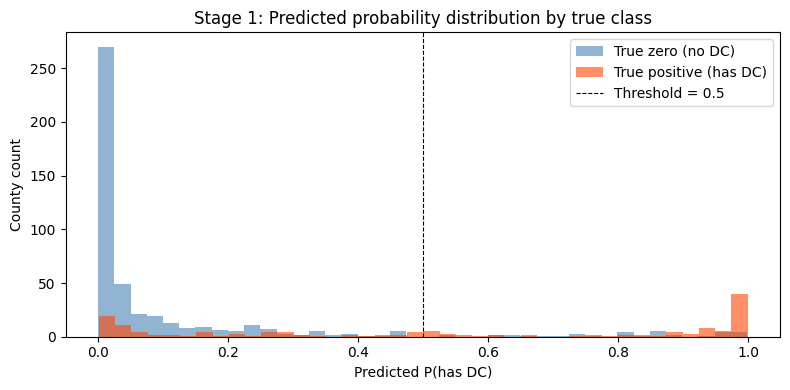

In [7]:
# Distribution of predicted probabilities by true class
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(s1_prob[y_test_bin == 0], bins=40, alpha=0.6, color='steelblue', label='True zero (no DC)')
ax.hist(s1_prob[y_test_bin == 1], bins=40, alpha=0.6, color='orangered', label='True positive (has DC)')
ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8, label='Threshold = 0.5')
ax.set_xlabel("Predicted P(has DC)")
ax.set_ylabel("County count")
ax.set_title("Stage 1: Predicted probability distribution by true class")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Stage 2 — Scale Regressor (Positive Counties Only)

Stage 2 is trained only on the 786 counties with `num_datacenters > 0`. The target is the
raw (non-zero) fractional count. Since we've removed the zeros, there is no zero-inflation —
the remaining distribution is right-skewed and strictly positive, matching a Gamma-like shape.

We use the Tweedie objective with `p` closer to 2 (Gamma regime) and tune it via a brief
5-fold CV on the positive training subset.

In [8]:
P_GRID_S2 = [1.2, 1.4, 1.6, 1.8, 1.9]
N_SPLITS_S2 = 5

BASE_S2 = dict(
    num_leaves=31,       # smaller tree since subset is ~630 counties
    min_child_samples=10,
    learning_rate=0.05,
    n_estimators=1000,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

kf = StratifiedKFold(n_splits=N_SPLITS_S2, shuffle=True, random_state=42)
# Stratify Stage 2 CV on whether count > median (rough balance of high/low within positives)
s2_strat = (y_train_pos > y_train_pos.median()).astype(int)

s2_cv_deviances  = {}
s2_cv_best_iters = {}

print(f"Stage 2 CV on {len(X_train_pos)} positive counties | p grid: {P_GRID_S2}")
print("-" * 55)

for p in P_GRID_S2:
    fold_deviances, fold_iters = [], []
    for tr_idx, val_idx in kf.split(X_train_pos, s2_strat):
        X_tr  = X_train_pos.iloc[tr_idx]
        X_val = X_train_pos.iloc[val_idx]
        y_tr  = y_train_pos.iloc[tr_idx]
        y_val = y_train_pos.iloc[val_idx]

        mdl = lgb.LGBMRegressor(
            objective="tweedie",
            tweedie_variance_power=p,
            **BASE_S2,
        )
        mdl.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=-1),
            ],
        )
        y_pred_val = np.maximum(mdl.predict(X_val), 1e-9)
        fold_deviances.append(mean_tweedie_deviance(y_val, y_pred_val, power=p))
        fold_iters.append(mdl.best_iteration_)

    s2_cv_deviances[p]  = np.mean(fold_deviances)
    s2_cv_best_iters[p] = int(np.median(fold_iters))
    print(f"  p={p:.1f}  deviance={s2_cv_deviances[p]:.5f}  median best_iter={s2_cv_best_iters[p]}")

best_p_s2 = min(s2_cv_deviances, key=s2_cv_deviances.get)
print(f"\nBest Stage 2 p = {best_p_s2}  (deviance = {s2_cv_deviances[best_p_s2]:.5f})")

Stage 2 CV on 614 positive counties | p grid: [1.2, 1.4, 1.6, 1.8, 1.9]
-------------------------------------------------------


  p=1.2  deviance=5.95028  median best_iter=50


  p=1.4  deviance=4.00392  median best_iter=40


  p=1.6  deviance=3.03810  median best_iter=43


  p=1.8  deviance=2.75855  median best_iter=29


  p=1.9  deviance=2.84856  median best_iter=13

Best Stage 2 p = 1.8  (deviance = 2.75855)


In [9]:
# Final Stage 2 model — train on all positive training counties
X_tr2, X_es2, y_tr2, y_es2 = train_test_split(
    X_train_pos, y_train_pos,
    test_size=0.10,
    random_state=42,
)

stage2 = lgb.LGBMRegressor(
    objective="tweedie",
    tweedie_variance_power=best_p_s2,
    num_leaves=31,
    min_child_samples=10,
    learning_rate=0.05,
    n_estimators=3000,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
stage2.fit(
    X_tr2, y_tr2,
    eval_set=[(X_es2, y_es2)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=75, verbose=False),
        lgb.log_evaluation(period=100),
    ],
)
print(f"\nStage 2 stopped at iteration {stage2.best_iteration_}")


Stage 2 stopped at iteration 22


In [10]:
import joblib
from pathlib import Path

MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

payload = {
    'stage1': stage1,
    'stage2': stage2,
    'best_p_s2': best_p_s2,
    'feature_names': list(X.columns),
}
MODEL_PATH = MODEL_DIR / 'option2_hurdle.joblib'
joblib.dump(payload, MODEL_PATH)
print(f'Saved: {MODEL_PATH}')
print(f'  stage1 best_iter = {stage1.best_iteration_}')
print(f'  stage2 best_iter = {stage2.best_iteration_}  (p={best_p_s2})')
print(f'  feature_names: {X.shape[1]} features')
print()
print('Load in another notebook with:')
print('  import joblib')
print(f'  obj    = joblib.load("{MODEL_PATH}")')
print('  stage1 = obj["stage1"]   # LGBMClassifier — P(has DC | X)')
print('  stage2 = obj["stage2"]   # LGBMRegressor  — E[count | DC present, X]')
print('  # Combined: stage1.predict_proba(X)[:,1] * stage2.predict(X)')

Saved: models/option2_hurdle.joblib
  stage1 best_iter = 163
  stage2 best_iter = 22  (p=1.8)
  feature_names: 37 features

Load in another notebook with:
  import joblib
  obj    = joblib.load("models/option2_hurdle.joblib")
  stage1 = obj["stage1"]   # LGBMClassifier — P(has DC | X)
  stage2 = obj["stage2"]   # LGBMRegressor  — E[count | DC present, X]
  # Combined: stage1.predict_proba(X)[:,1] * stage2.predict(X)


In [11]:
# Stage 2 evaluation on positive test counties only
s2_pred_pos = np.maximum(stage2.predict(X_test_pos), 1e-9)

s2_mae_log  = mean_absolute_error(np.log1p(y_test_pos), np.log1p(s2_pred_pos))
s2_rmse_log = np.sqrt(mean_squared_error(np.log1p(y_test_pos), np.log1p(s2_pred_pos)))
s2_dev      = mean_tweedie_deviance(y_test_pos, s2_pred_pos, power=best_p_s2)

print("=" * 45)
print(f"  Stage 2 — positive counties only ({len(y_test_pos)})")
print(f"  Tweedie deviance (p={best_p_s2}): {s2_dev:.5f}")
print(f"  MAE  (log1p scale):   {s2_mae_log:.4f}")
print(f"  RMSE (log1p scale):   {s2_rmse_log:.4f}")
print("=" * 45)

  Stage 2 — positive counties only (153)
  Tweedie deviance (p=1.8): 2.03178
  MAE  (log1p scale):   0.5958
  RMSE (log1p scale):   0.7584


## 6. Combined Prediction

The hurdle prediction for all counties:
```
E[y | X]  =  P(y > 0 | X)  ×  E[y | y > 0, X]
```
Stage 2 is applied to **all** test counties (not just the positive ones) — this is correct
because Stage 2 estimates "what would the count be IF this county had DCs?", and Stage 1
weights it by the probability of that scenario being true.

In [12]:
# P(y > 0 | X) from Stage 1
prob_pos   = stage1.predict_proba(X_test)[:, 1]

# E[y | y > 0, X] from Stage 2 (applied to all counties)
scale_pred = np.maximum(stage2.predict(X_test), 1e-9)

# Combined hurdle prediction
y_pred_combined = prob_pos * scale_pred

# Full evaluation
mae_log     = mean_absolute_error(np.log1p(y_test), np.log1p(y_pred_combined))
rmse_log    = np.sqrt(mean_squared_error(np.log1p(y_test), np.log1p(y_pred_combined)))
tweedie_dev = mean_tweedie_deviance(y_test, np.maximum(y_pred_combined, 1e-9), power=1.3)
auc         = roc_auc_score(y_test_bin, y_pred_combined)
median_ae   = float(np.median(np.abs(y_test - y_pred_combined)))

print("=" * 55)
print("  Combined hurdle prediction — all test counties")
print("=" * 55)
print(f"  Tweedie deviance (p=1.3, for Option 1 comparison): {tweedie_dev:.5f}")
print(f"  MAE  (log1p scale):                                {mae_log:.4f}")
print(f"  RMSE (log1p scale):                                {rmse_log:.4f}")
print(f"  AUC  (has any DC):                                 {auc:.4f}")
print(f"  Median AE (raw scale):                             {median_ae:.3f}  data centers")
print("=" * 55)

  Combined hurdle prediction — all test counties
  Tweedie deviance (p=1.3, for Option 1 comparison): 1.96482
  MAE  (log1p scale):                                0.2790
  RMSE (log1p scale):                                0.5236
  AUC  (has any DC):                                 0.8328
  Median AE (raw scale):                             0.052  data centers


### Diagnostic Plots

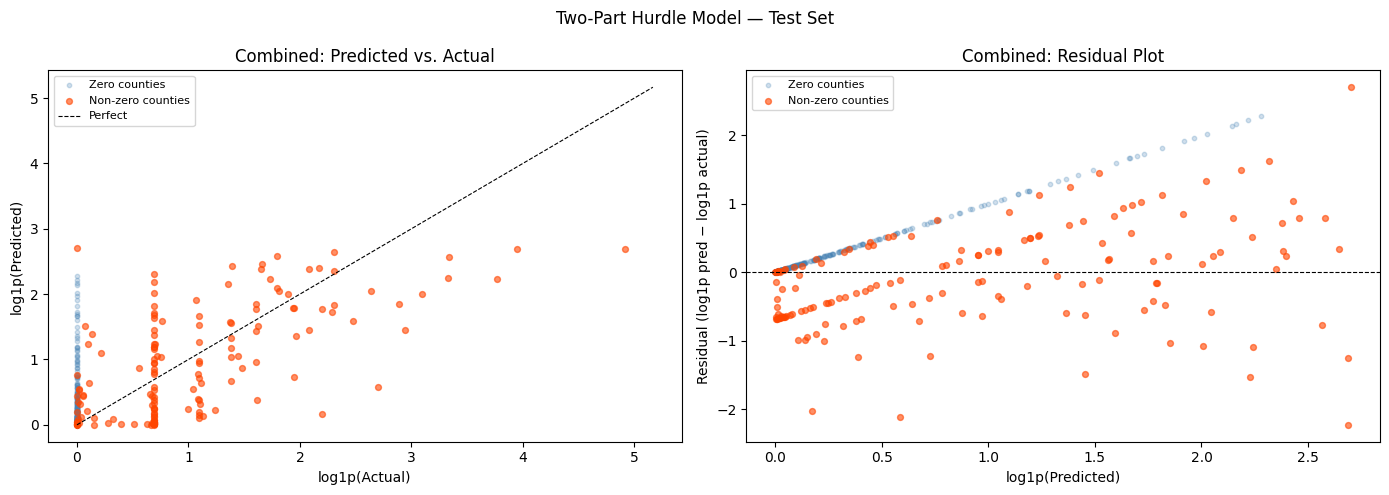

In [13]:
has_dc     = y_test_bin.values.astype(bool)
log_actual = np.log1p(y_test.values)
log_pred   = np.log1p(y_pred_combined)
residuals  = log_pred - log_actual

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(log_actual[~has_dc], log_pred[~has_dc],
           alpha=0.25, s=10, color='steelblue', label='Zero counties')
ax.scatter(log_actual[has_dc], log_pred[has_dc],
           alpha=0.6, s=18, color='orangered', label='Non-zero counties')
lim = max(log_actual.max(), log_pred.max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8, label='Perfect')
ax.set_xlabel("log1p(Actual)")
ax.set_ylabel("log1p(Predicted)")
ax.set_title("Combined: Predicted vs. Actual")
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(log_pred[~has_dc], residuals[~has_dc],
           alpha=0.25, s=10, color='steelblue', label='Zero counties')
ax.scatter(log_pred[has_dc], residuals[has_dc],
           alpha=0.6, s=18, color='orangered', label='Non-zero counties')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel("log1p(Predicted)")
ax.set_ylabel("Residual (log1p pred − log1p actual)")
ax.set_title("Combined: Residual Plot")
ax.legend(fontsize=8)

plt.suptitle("Two-Part Hurdle Model — Test Set", fontsize=12)
plt.tight_layout()
plt.show()

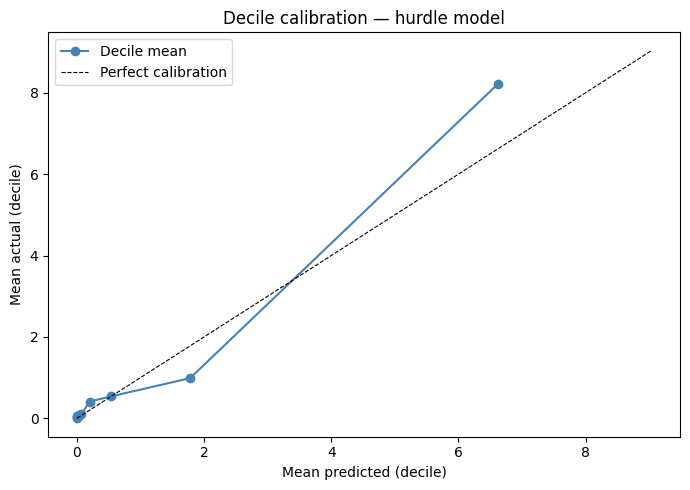

        actual   pred
decile               
0        0.031  0.001
1        0.003  0.004
2        0.050  0.008
3        0.046  0.016
4        0.084  0.031
5        0.102  0.073
6        0.412  0.199
7        0.537  0.533
8        0.989  1.782
9        8.213  6.619


In [14]:
calib = pd.DataFrame({"actual": y_test.values, "pred": y_pred_combined})
calib["decile"] = pd.qcut(calib["pred"], q=10, labels=False, duplicates="drop")
decile_summary = calib.groupby("decile")[["actual", "pred"]].mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(decile_summary["pred"], decile_summary["actual"],
        marker='o', color='steelblue', label='Decile mean')
ref_max = max(decile_summary["pred"].max(), decile_summary["actual"].max()) * 1.1
ax.plot([0, ref_max], [0, ref_max], 'k--', linewidth=0.8, label='Perfect calibration')
ax.set_xlabel("Mean predicted (decile)")
ax.set_ylabel("Mean actual (decile)")
ax.set_title("Decile calibration — hurdle model")
ax.legend()
plt.tight_layout()
plt.show()

print(decile_summary.round(3).to_string())

## 7. SHAP Analysis — Presence vs. Scale

This is the central analytical advantage of Option 2. We compute SHAP values separately
for each stage:

- **Stage 1 SHAP**: contributions to `log-odds P(y > 0 | X)` — what makes a county
  more or less likely to have *any* data center
- **Stage 2 SHAP**: contributions to `log E[y | y > 0, X]` — what makes a county
  with data centers have *more or fewer*

Note: the two sets of SHAP values are on different scales (logit vs. log-count) and
cannot be compared directly by magnitude — only the feature rankings are directly comparable.

In [15]:
# Stage 1 SHAP — all test counties
exp1 = shap.TreeExplainer(stage1)
sv1  = exp1.shap_values(X_test)
# LGBMClassifier returns a list [class0_shap, class1_shap]; take class 1
if isinstance(sv1, list):
    sv1 = sv1[1]

# Stage 2 SHAP — positive test counties only
exp2 = shap.TreeExplainer(stage2)
sv2  = exp2.shap_values(X_test_pos)

print(f"Stage 1 SHAP shape: {sv1.shape}  (all test counties)")
print(f"Stage 2 SHAP shape: {sv2.shape}  (positive test counties)")

Stage 1 SHAP shape: (628, 37)  (all test counties)
Stage 2 SHAP shape: (153, 37)  (positive test counties)


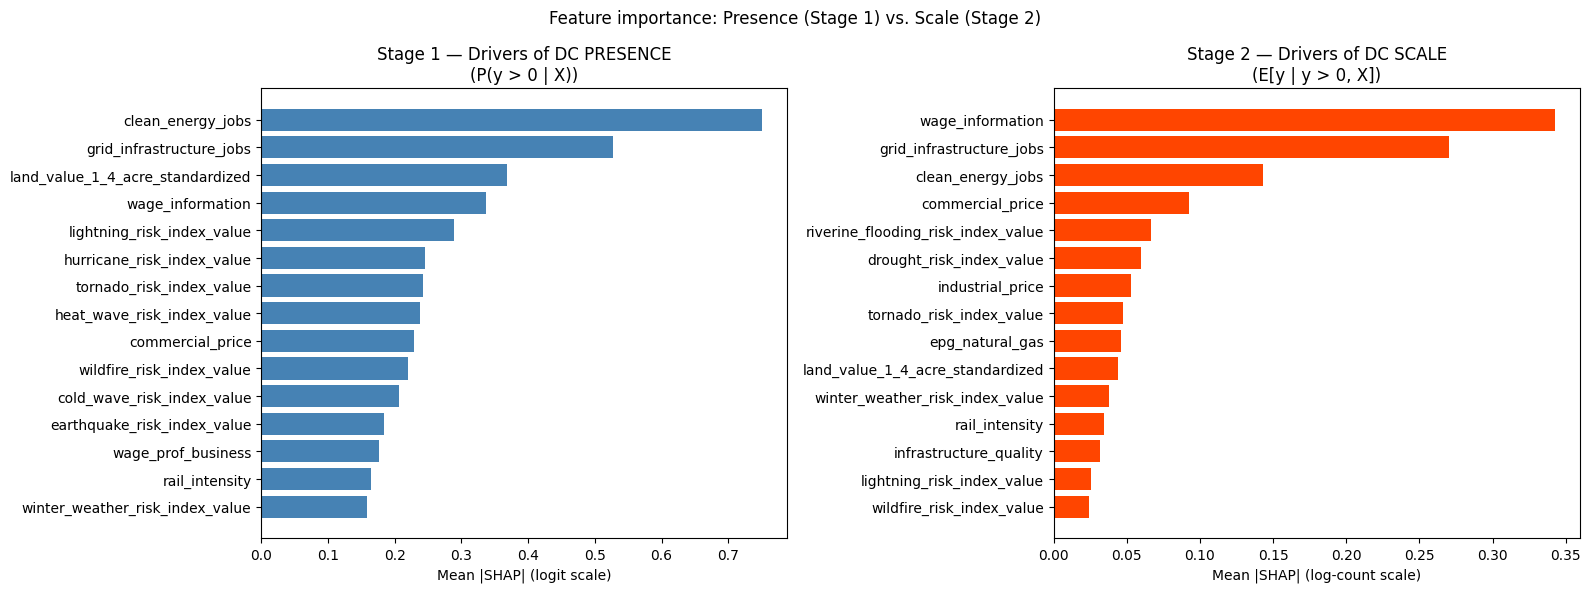

In [16]:
# Side-by-side bar charts: top 15 features by mean |SHAP| for each stage
TOP_N = 15

mean_abs_s1 = pd.Series(np.abs(sv1).mean(axis=0), index=X_test.columns)
mean_abs_s2 = pd.Series(np.abs(sv2).mean(axis=0), index=X_test_pos.columns)

top_s1 = mean_abs_s1.sort_values(ascending=False).head(TOP_N)
top_s2 = mean_abs_s2.sort_values(ascending=False).head(TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stage 1
ax = axes[0]
ax.barh(top_s1.index[::-1], top_s1.values[::-1], color='steelblue')
ax.set_xlabel("Mean |SHAP| (logit scale)")
ax.set_title("Stage 1 — Drivers of DC PRESENCE\n(P(y > 0 | X))")

# Stage 2
ax = axes[1]
ax.barh(top_s2.index[::-1], top_s2.values[::-1], color='orangered')
ax.set_xlabel("Mean |SHAP| (log-count scale)")
ax.set_title(f"Stage 2 — Drivers of DC SCALE\n(E[y | y > 0, X])")

plt.suptitle("Feature importance: Presence (Stage 1) vs. Scale (Stage 2)", fontsize=12)
plt.tight_layout()
plt.show()

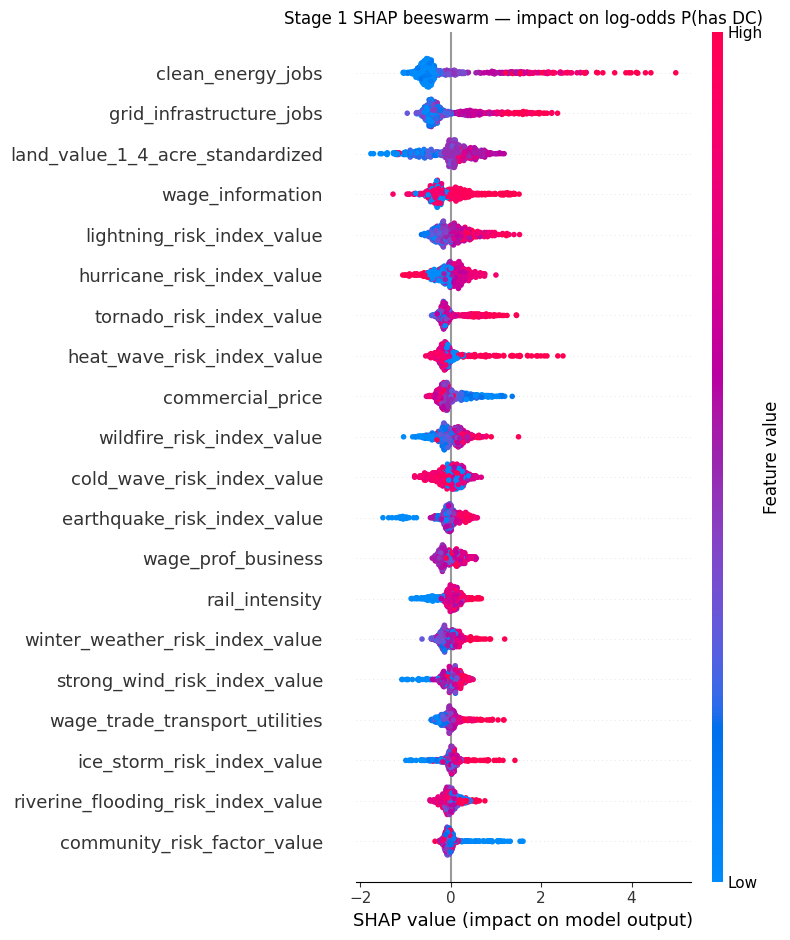

In [17]:
# Stage 1 beeswarm
plt.figure(figsize=(10, 7))
shap.summary_plot(sv1, X_test, show=False, max_display=20)
plt.title("Stage 1 SHAP beeswarm — impact on log-odds P(has DC)")
plt.tight_layout()
plt.show()

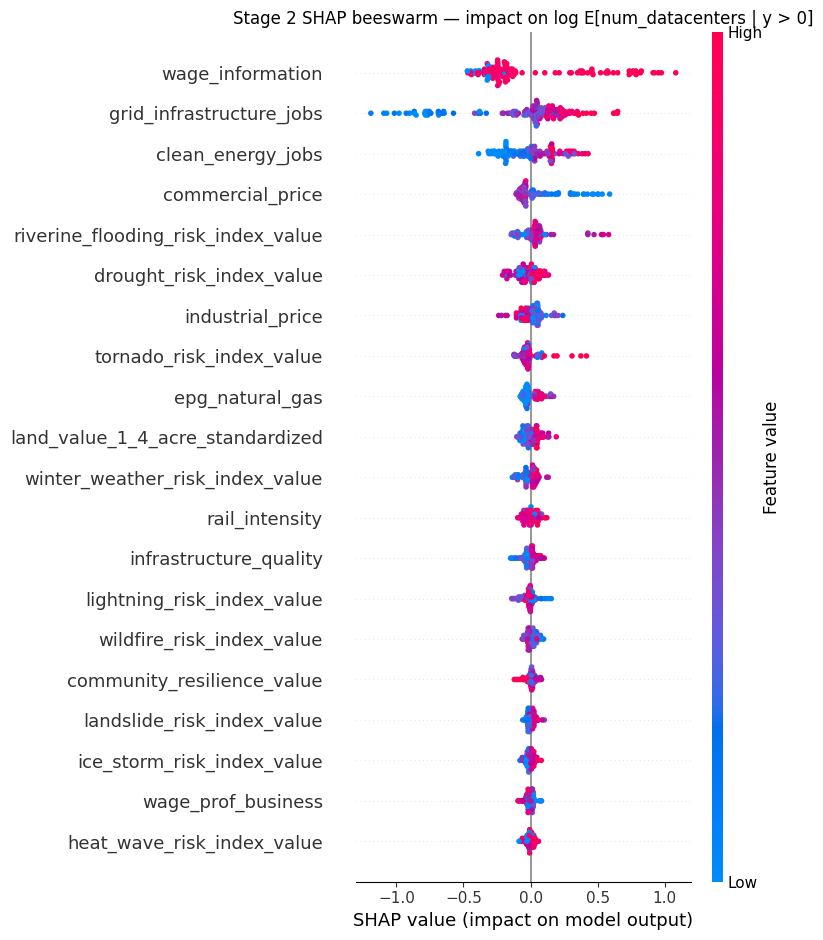

In [18]:
# Stage 2 beeswarm
plt.figure(figsize=(10, 7))
shap.summary_plot(sv2, X_test_pos, show=False, max_display=20)
plt.title("Stage 2 SHAP beeswarm — impact on log E[num_datacenters | y > 0]")
plt.tight_layout()
plt.show()

## 8. Option 1 vs. Option 2 — Metric Comparison

We report both models on the same test set with the same metrics, using Tweedie deviance
at `p=1.3` (Option 1's best p) as the shared comparison metric.

In [19]:
comparison = pd.DataFrame({
    "Option 1 (Tweedie)": {
        "Tweedie deviance (p=1.3)": 1.75550,
        "MAE (log1p)": 0.3120,
        "RMSE (log1p)": 0.4736,
        "AUC (has any DC)": 0.8074,
        "Median AE (raw)": 0.185,
    },
    "Option 2 (Hurdle)": {
        "Tweedie deviance (p=1.3)": tweedie_dev,
        "MAE (log1p)": mae_log,
        "RMSE (log1p)": rmse_log,
        "AUC (has any DC)": auc,
        "Median AE (raw)": median_ae,
    },
})
print(comparison.round(4).to_string())

                          Option 1 (Tweedie)  Option 2 (Hurdle)
Tweedie deviance (p=1.3)              1.7555             1.9648
MAE (log1p)                           0.3120             0.2790
RMSE (log1p)                          0.4736             0.5236
AUC (has any DC)                      0.8074             0.8328
Median AE (raw)                       0.1850             0.0525


## 9. Summary

### Models
- **Stage 1**: LGBMClassifier — binary presence, `is_unbalance=True`, early stopping on AUC
- **Stage 2**: LGBMRegressor — Tweedie on positive counties only, `p` tuned via 5-fold CV
- **Features**: 37 structural features — `state` excluded (see Section 2)
- **Combined**: `E[y|X] = P(y>0|X) × E[y|y>0,X]`

### Key interpretive output
The side-by-side SHAP bar charts (Section 7) are the primary deliverable of Option 2.
They answer two distinct policy questions:
1. **What makes a county attractive enough to get *any* data center?** → Stage 1 SHAP
2. **Among counties that already have DCs, what drives them to have more?** → Stage 2 SHAP

If the two rankings differ substantially, the hurdle formulation is revealing genuine
structural heterogeneity in the data generating process. If they look similar, Option 1's
simpler single-model structure is sufficient.

### When to prefer each option
| | Option 1 (Tweedie) | Option 2 (Hurdle) |
|---|---|---|
| Goal | Best overall prediction | Interpretive richness |
| Output | Single score | Presence prob + scale estimate |
| SHAP | One blended chart | Separate presence vs. scale charts |
| Complexity | Lower | Higher |